In [1]:
import pandas as pd


reviews_all = pd.read_excel('reviews_all.xlsx')

# Быстрый обзор структуры
print(reviews_all.shape)      # (число строк, число столбцов)
print(reviews_all.columns)    # названия столбцов
reviews_all.head(5)           # первые 5 записей
reviews_all.info()            # типы данных и непустые значения


(94009, 7)
Index(['source', 'chain', 'year', 'author', 'rating', 'text', 'reactions'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94009 entries, 0 to 94008
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   source     94009 non-null  object 
 1   chain      94009 non-null  object 
 2   year       93907 non-null  float64
 3   author     85124 non-null  object 
 4   rating     94009 non-null  int64  
 5   text       93906 non-null  object 
 6   reactions  94009 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 5.0+ MB


In [3]:
pip install pymorphy3

Note: you may need to restart the kernel to use updated packages.


In [7]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/anna_maltseva/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [8]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/anna_maltseva/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [9]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/anna_maltseva/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [10]:
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/anna_maltseva/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [23]:
import re
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk import pos_tag
from pymorphy3 import MorphAnalyzer
from Levenshtein import ratio
from collections import Counter
from tqdm.auto import tqdm
from typing import List
from sklearn.base import BaseEstimator, TransformerMixin


"""Предобработка текстов"""

    
class TextCleaner(BaseEstimator, TransformerMixin):
    def __init__(self, text_col='text', use_lev_merge=False, lev_threshold=0.85):
        self.text_col = text_col
        self.use_lev_merge = use_lev_merge
        self.lev_threshold = lev_threshold

        self.stop_ru = set(stopwords.words('russian'))
        self.stop_en = set(stopwords.words('english'))
        self.lemm_en = WordNetLemmatizer()
        self.morph_ru = MorphAnalyzer()

    def fit(self, X, y=None):
        return self

    def _clean(self, text: str) -> str:
        text = text.lower()
        return re.sub(r'http\S+|\d+|[^a-zа-яё\s]', ' ', text)

    def _process_ru(self, tokens: List[str]) -> List[str]: # Лемматизируем и фильтруем короткие и стоп-слова
        return [
            w for w in (self.morph_ru.parse(t)[0].normal_form for t in tokens)
            if w not in self.stop_ru and len(w) > 2
        ]

    def _process_en(self, tokens: List[str], tags: List[tuple]) -> List[str]:
        res = []   # Лемматизируем английские слова с учётом POS-тегов
        for w, tg in zip(tokens, tags):
            if w in self.stop_en or len(w) < 3:
                continue
            pos = tg[1][0].lower()  # tg = (word, POS)
            pos = {'j':'a','v':'v','n':'n'}.get(pos, 'n')
            res.append(self.lemm_en.lemmatize(w, pos))
        return res

    def merge_similar_lemmas(self, docs: List[List[str]]) -> List[List[str]]: #левенштейн
        # 1) считаем частоты
        freq = Counter(tok for doc in docs for tok in doc)
        unique = list(freq.keys())

        # 2) группируем по длине для ускорения
        buckets = {}
        for tok in unique:
            buckets.setdefault(len(tok), []).append(tok)

        # 3) строим маппинг
        rep_map = {}
        for length, toks in buckets.items():
            for i, tok in enumerate(toks):
                for other in toks[i+1:]:
                    if ratio(tok, other) >= self.lev_threshold:
                        # выбираем более частотное
                        rep = tok if freq[tok] >= freq[other] else other
                        rep_map[tok] = rep
                        rep_map[other] = rep

        # 4) заменяем в документах
        merged = [
            [rep_map.get(tok, tok) for tok in doc]
            for doc in docs
        ]
        return merged

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy() # Копируем DataFrame, чтобы не модифицировать исходный
        docs = []
        for txt in df[self.text_col].fillna(''):
            clean_txt = self._clean(txt) # 1) Очистка текста
            tokens = word_tokenize(clean_txt, language='russian') # 2) Токенизация
            if re.search('[а-яё]', clean_txt):  # 3) Выбор обработки по языку
                lemms = self._process_ru(tokens)
            else:
                tags = pos_tag(tokens)
                lemms = self._process_en(tokens, tags)
            docs.append(lemms)

        if self.use_lev_merge: # 4) Опциональное объединение похожих лемм
            docs = self.merge_similar_lemmas(docs)

        df['clean_text'] = [' '.join(doc) for doc in docs]
        return df # 5) Формируем новый столбец 
    
prep = TextCleaner(text_col='text', use_lev_merge=True, lev_threshold=0.85)
reviews_clean = prep.fit_transform(reviews_all)
reviews_clean[['text','clean_text']].head()

,text,clean_text
0,"Магазин сам по себе хороший, ассортимент радуе...",магазин хороший ассортимент радовать заграничн...
1,"Хороший ассортимент,нашла здесь марки,которых ...",хороший ассортимент найти марка который нигде ...
2,Большой магазин с хорошим ассортиментом.Вежлив...,большой магазин хороший ассортимент вежливый к...
3,"Отличный магазин, покупал жене подарок не на о...",отличный магазин покупать жена подарок праздни...
4,"Магазин находится в центре города, очень уютна...",магазин находиться центр город очень уютный ат...


In [75]:
import pandas as pd
from gensim import corpora, models
from gensim.models.coherencemodel import CoherenceModel

# Функция для перебора числа тем и расчёта coherence
def find_best_n(texts, start=3, end=10):

    # токенизируем по пробелам
    texts_tokenized = [doc.split() for doc in texts]
    #  строим словарь gensim
    dictionary = corpora.Dictionary(texts_tokenized)
    corpus = [dictionary.doc2bow(txt) for txt in texts_tokenized]
    
    best_n, best_score = None, -1
    for n in range(start, end+1):
        # обучаем модель Gensim LDA
        model = models.LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=n,
            passes=5,
            random_state=42
        )
        # считаем coherence
        cm = CoherenceModel(
            model=model,
            texts=texts_tokenized,
            dictionary=dictionary,
            coherence='c_v'
        )
        score = cm.get_coherence()
        print(f"  n={n}: coherence = {score:.3f}")
        if score > best_score:
            best_score, best_n = score, n

    print(f" Лучшее число тем: {best_n} (coherence={best_score:.3f})\n")
    return best_n

# Применяем для каждой сети
top_chains = ["Золотое яблоко", "Рив Гош", "Лэтуаль"]

for chain in top_chains:
    subset = reviews_clean[reviews_clean['chain']==chain]
    texts = subset['clean_text'].tolist()
    print(f" {chain}: {len(texts)} отзывов ")
    # Перебор с n от 3 до 10
    best_n = find_best_n(texts, start=3, end=10)


 Золотое яблоко: 10426 отзывов 
  n=3: coherence = 0.517
  n=4: coherence = 0.528
  n=5: coherence = 0.516
  n=6: coherence = 0.514
  n=7: coherence = 0.542
  n=8: coherence = 0.528
  n=9: coherence = 0.509
  n=10: coherence = 0.514
 Лучшее число тем: 7 (coherence=0.542)

 Рив Гош: 10973 отзывов 
  n=3: coherence = 0.497
  n=4: coherence = 0.513
  n=5: coherence = 0.488
  n=6: coherence = 0.500
  n=7: coherence = 0.486
  n=8: coherence = 0.494
  n=9: coherence = 0.510
  n=10: coherence = 0.491
 Лучшее число тем: 4 (coherence=0.513)

 Лэтуаль: 19298 отзывов 
  n=3: coherence = 0.593
  n=4: coherence = 0.582
  n=5: coherence = 0.575
  n=6: coherence = 0.598
  n=7: coherence = 0.535
  n=8: coherence = 0.524
  n=9: coherence = 0.555
  n=10: coherence = 0.538
 Лучшее число тем: 6 (coherence=0.598)



In [80]:
best_n_by_chain = {
    "Золотое яблоко": 7,
    "Рив Гош":4,
    "Лэтуаль":6
}
all_stats = []

for chain in top_chains:
    subset = reviews_clean[reviews_clean.chain == chain].copy()
    texts = subset['clean_text'].tolist()
    n_topics = best_n_by_chain[chain]
    print(f"\n{chain}: обучаем LDA на {n_topics} темах")

    # 1. Векторизация
    dtm = vect.fit_transform(texts)

    # 2. Обучение LDA
    lda = LatentDirichletAllocation(
        n_components=n_topics,
        max_iter=10,
        learning_method='batch',
        random_state=42
    )
    lda.fit(dtm)

    # 3. Печать тем
    feature_names = vect.get_feature_names_out()
    print_top_words(lda, feature_names, n_top_words=7)

    # 4. Определяем доминантную тему для каждого отзыва
    doc_topic = lda.transform(dtm)            # матрица (n_docs, n_topics)
    dominant = doc_topic.argmax(axis=1) + 1   # темы с 1 по n_topics
    subset['topic'] = dominant                # теперь столбец topic в subset

    # 5. Собираем статистику
    stats = subset.groupby('topic').agg(
        n_reviews    = ('topic','size'),
        pct_reviews  = ('topic', lambda x: 100 * len(x) / len(subset)),
        avg_rating   = ('rating','mean'),
        avg_reactions= ('reactions','mean')
    ).reset_index()
    stats['chain'] = chain
    all_stats.append(stats)

# 6. Объединяем результаты
all_stats_df = pd.concat(all_stats, ignore_index=True)


Золотое яблоко: обучаем LDA на 7 темах
    Тема 1: спасибо, помочь, подобрать, покупка, довольный, прекрасный, приятный
    Тема 2: цена, скидка, косметика, ассортимент, товар, хороший, акция
    Тема 3: хороший, выбор, персонал, вежливый, большой, ассортимент, косметика
    Тема 4: заказ, товар, доставка, деньга, карта, возврат, поддержка
    Тема 5: персонал, отличный, приветливый, продукция, подсказать, вода, отношение
    Тема 6: аромат, дух, парфюм, покупка, подарок, дать, пробник
    Тема 7: охранник, товар, покупка, косметика, продукт, нужный, большой

Рив Гош: обучаем LDA на 4 темах
    Тема 1: выбор, хороший, персонал, большой, вежливый, помочь, ассортимент
    Тема 2: косметика, скидка, ассортимент, акция, хороший, цена, товар
    Тема 3: аромат, спасибо, помочь, сотрудник, большой, подобрать, парфюм
    Тема 4: товар, заказ, косметика, карта, покупка, деньга, отношение

Лэтуаль: обучаем LDA на 6 темах
    Тема 1: заказ, товар, интернет, ждать, деньга, приложение, доставка
 

In [117]:
import pyLDAvis
import pyLDAvis.gensim_models
from IPython.display import display
from gensim import corpora, models

def make_vis(chain_name, n_topics):
    # отфильтровали по сети
    subset = reviews_clean[reviews_clean.chain == chain_name]
    texts_tok = [doc.split() for doc in subset['clean_text']]
    # словарь и корпус
    dct    = corpora.Dictionary(texts_tok)
    corpus = [dct.doc2bow(txt) for txt in texts_tok]
    # обучили модель
    lda = models.LdaModel(corpus, id2word=dct, num_topics=n_topics, random_state=42)
    # подготовили визуализацию
    return pyLDAvis.gensim_models.prepare(lda, corpus, dct)


In [119]:
# создаём три дашборда
vis_zy = make_vis("Золотое яблоко", 7)


pyLDAvis.enable_notebook()
display(vis_zy)


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
3     -0.018052 -0.059133       1        1  24.413857
0     -0.224633  0.094668       2        1  23.357039
1     -0.061926 -0.132880       3        1  11.588033
6      0.132287  0.061747       4        1  11.523846
2      0.001482  0.083298       5        1  10.262676
5     -0.023101 -0.059567       6        1   9.944711
4      0.193942  0.011867       7        1   8.909838, topic_info=             Term         Freq        Total Category  logprob  loglift
394         заказ  1677.000000  1677.000000  Default  30.0000  30.0000
62          очень  3530.000000  3530.000000  Default  29.0000  29.0000
11        магазин  7359.000000  7359.000000  Default  28.0000  28.0000
31        хороший  2047.000000  2047.000000  Default  27.0000  27.0000
36          выбор  2085.000000  2085.000000  Default  26.0000  26.0000
..            ...          ...          ...      ...      ...      ...
240         акция   176.750109  1126.119581   Topic7  -4.8992   0.5662
61   обслуживание   147.147965   589.971384   Topic7  -5.0825   1.0294
65          товар   194.144719  2681.343945   Topic7  -4.8053  -0.2075
281       приятно   133.304651   471.436151   Topic7  -5.1813   1.1549
143       покупка   136.560771  1316.790303   Topic7  -5.1572   0.1518

[591 rows x 6 columns], token_table=      Topic      Freq    Term
term                         
3511      5  0.945137    blue
627       1  0.059313  chanel
627       5  0.889699  chanel
627       6  0.039542  chanel
5127      1  0.975698  malone
...     ...       ...     ...
902       4  0.000591  яблоко
902       5  0.156746  яблоко
902       6  0.318816  яблоко
902       7  0.000591  яблоко
4135      4  0.984207   явный

[1547 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[4, 1, 2, 7, 3, 6, 5])

In [120]:
vis_rg = make_vis("Рив Гош",       4)
pyLDAvis.enable_notebook()
display(vis_rg)

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
1     -0.088444  0.042163       1        1  29.716900
3      0.095933 -0.018196       2        1  26.982242
0     -0.040820 -0.084604       3        1  24.875667
2      0.033331  0.060637       4        1  18.425191, topic_info=             Term         Freq        Total Category  logprob  loglift
126    парфюмерия  2410.000000  2410.000000  Default  30.0000  30.0000
100        скидка  1361.000000  1361.000000  Default  29.0000  29.0000
116     косметика  3201.000000  3201.000000  Default  28.0000  28.0000
1036         сеть  2651.000000  2651.000000  Default  27.0000  27.0000
0     консультант  3031.000000  3031.000000  Default  26.0000  26.0000
...           ...          ...          ...      ...      ...      ...
116     косметика   254.913539  3201.351040   Topic4  -5.2993  -0.8390
117      покупать   190.628910   992.223878   Topic4  -5.5899   0.0418
68           рива   253.225154  4560.072812   Topic4  -5.3059  -1.1994
152          день   179.192615  1030.926304   Topic4  -5.6518  -0.0583
134          цена   185.035102  1716.326478   Topic4  -5.6197  -0.5359

[389 rows x 6 columns], token_table=      Topic      Freq        Term
term                             
7496      4  0.940742      afgano
7247      4  0.952699       black
3730      3  0.973771     lancome
7742      2  0.036572  абсолютный
7742      4  0.950879  абсолютный
...     ...       ...         ...
207       3  0.162191         это
207       4  0.266221         это
3040      1  0.032718      этуаля
3040      2  0.032718      этуаля
3040      4  0.916117      этуаля

[813 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[2, 4, 1, 3])

In [121]:
vis_le = make_vis("Лэтуаль",       6)
pyLDAvis.enable_notebook()
display(vis_le)

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
2      0.117577 -0.120949       1        1  26.048751
1     -0.127015 -0.025362       2        1  19.129440
5      0.135370  0.006424       3        1  17.093379
4     -0.215288 -0.011137       4        1  15.356465
0      0.039470 -0.019004       5        1  15.211325
3      0.049887  0.170029       6        1   7.160641, topic_info=          Term         Freq        Total Category  logprob  loglift
148      заказ  2920.000000  2920.000000  Default  30.0000  30.0000
140    хороший  4337.000000  4337.000000  Default  29.0000  29.0000
349      выбор  3299.000000  3299.000000  Default  28.0000  28.0000
230   охранник  1725.000000  1725.000000  Default  27.0000  27.0000
54        цена  1722.000000  1722.000000  Default  26.0000  26.0000
...        ...          ...          ...      ...      ...      ...
109   персонал   118.846373  2985.936588   Topic6  -5.3972  -0.5873
39     большой   116.816153  3265.946499   Topic6  -5.4144  -0.6941
195   продавец   100.053306  2824.051869   Topic6  -5.5693  -0.7037
1072  выбирать    94.521824   512.006332   Topic6  -5.6262   0.9471
202     парфюм    96.264592  1286.015321   Topic6  -5.6079   0.0444

[510 rows x 6 columns], token_table=      Topic      Freq           Term
term                                
969       3  0.045891           dior
969       5  0.940760           dior
2812      6  0.943521         август
1440      2  0.030943  администрация
1440      5  0.959234  администрация
...     ...       ...            ...
819       6  0.680892           юлия
2347      1  0.009948           ящик
2347      2  0.009948           ящик
2347      3  0.964940           ящик
2347      5  0.009948           ящик

[1377 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[3, 2, 6, 5, 1, 4])

In [123]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import pandas as pd

# 1) Обновлённый словарь читаемых названий тем
topic_names = {
    "Золотое яблоко": {
        1: "Подбор продукции и благодарности",  # объединили старые 1+6
        2: "Цены и акции",
        3: "Ассортимент",
        4: "Онлайн-заказ и возвраты",
        5: "Отношения с персоналом",
        7: "Охрана и контроль"
    },
    "Рив Гош": {
        1: "Ассортимент и сервис",
        2: "Цены и скидки",
        3: "Ароматы и подбор",
        4: "Покупка и возвраты"
    },
    "Лэтуаль": {
        1: "Онлайн-сервис",
        2: "Консультации и помощь",
        3: "Тестеры и охрана",
        4: "Ассортимент",
        5: "Цены и акции",
        6: "Оплата и кассы"
    }
}

# 2) Векторизатор
vect = CountVectorizer(
    stop_words=full_stop_list,
    max_df=0.75,
    min_df=15,
    max_features=3000,
    ngram_range=(1,2)
)

all_stats = []

for chain, n_topics in best_n_by_chain.items():
    subset = reviews_clean[reviews_clean['chain'] == chain].copy()
    texts  = subset['clean_text'].tolist()
    if len(texts) < 50:
        continue

    # 3) Обучаем LDA
    dtm = vect.fit_transform(texts)
    lda = LatentDirichletAllocation(
        n_components=n_topics,
        max_iter=10,
        learning_method='batch',
        random_state=42
    )
    lda.fit(dtm)

    # 4) Назначаем каждой записи доминантную тему
    doc_topic        = lda.transform(dtm)
    subset['topic']  = doc_topic.argmax(axis=1) + 1

    # 4.1) Склеиваем темы 6→1 для «Золотого яблока»
    if chain == "Золотое яблоко":
        subset.loc[subset['topic'] == 6, 'topic'] = 1

    # 5) Маппим номера тем на читаемые лейблы
    subset['topic_label'] = subset['topic'].map(topic_names[chain])

    # 6) Собираем статистику
    stats = subset.groupby(['chain','topic','topic_label']).agg(
        n_reviews     = ('topic', 'size'),
        pct_reviews   = ('topic', lambda x: 100 * len(x) / len(subset)),
        avg_rating    = ('rating','mean'),
        avg_reactions = ('reactions','mean'),
        first_year    = ('year','min'),
        last_year     = ('year','max')
    ).reset_index()

    all_stats.append(stats)

# 7) Итоговая таблица
all_stats_df = pd.concat(all_stats, ignore_index=True)
display(all_stats_df)


,chain,topic,topic_label,n_reviews,pct_reviews,avg_rating,avg_reactions,first_year,last_year
0,Золотое яблоко,1,Подбор продукции и благодарности,3017,28.937272,3.646006,2.825655,2011.0,2025.0
1,Золотое яблоко,2,Цены и акции,1726,16.554767,4.205098,3.723059,2010.0,2025.0
2,Золотое яблоко,3,Ассортимент,2681,25.714560,4.809772,2.190974,2014.0,2025.0
3,Золотое яблоко,4,Онлайн-заказ и возвраты,1050,10.070976,1.612381,2.952381,2011.0,2025.0
4,Золотое яблоко,5,Отношения с персоналом,807,7.740265,3.890954,2.332094,2015.0,2025.0
5,Золотое яблоко,7,Охрана и контроль,1145,10.982160,2.910917,3.459389,2015.0,2025.0
6,Рив Гош,1,Ассортимент и сервис,3255,29.663720,4.638402,2.087250,2011.0,2025.0
7,Рив Гош,2,Цены и скидки,2310,21.051672,4.265801,2.735931,2010.0,2025.0
8,Рив Гош,3,Ароматы и подбор,2836,25.845257,3.518688,2.741890,2011.0,2025.0
9,Рив Гош,4,Покупка и возвраты,2572,23.439351,2.007776,2.837481,2011.0,2025.0


In [125]:
def make_vis(chain_name, n_topics):
    subset = reviews_clean[reviews_clean.chain == chain_name]
    texts_tok = [doc.split() for doc in subset['clean_text']]
    dct    = corpora.Dictionary(texts_tok)
    corpus = [dct.doc2bow(txt) for txt in texts_tok]
    lda    = models.LdaModel(
        corpus, 
        id2word=dct, 
        num_topics=n_topics, 
        random_state=42
    )
    return pyLDAvis.gensim_models.prepare(lda, corpus, dct)

pyLDAvis.enable_notebook()

# Для «Золотого яблока» теперь 6 тем
vis_zy = make_vis("Золотое яблоко", 6)

display(vis_zy)

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
3     -0.019066  0.039977       1        1  28.481347
0     -0.225838 -0.079682       2        1  25.748298
2      0.041015 -0.067024       3        1  14.749746
5      0.047180  0.035311       4        1  11.321959
1     -0.020605  0.145583       5        1  10.756145
4      0.177314 -0.074164       6        1   8.942505, topic_info=              Term         Freq        Total Category  logprob  loglift
394          заказ  1652.000000  1652.000000  Default  30.0000  30.0000
196    супермаркет   807.000000   807.000000  Default  29.0000  29.0000
62           очень  3347.000000  3347.000000  Default  28.0000  28.0000
11         магазин  7219.000000  7219.000000  Default  27.0000  27.0000
0      ассортимент  1668.000000  1668.000000  Default  26.0000  26.0000
..             ...          ...          ...      ...      ...      ...
45   рекомендовать   124.705604   456.956349   Topic6  -5.2517   1.1157
281        приятно   123.214379   466.397005   Topic6  -5.2637   1.0832
336          любой   120.486430   479.203404   Topic6  -5.2861   1.0338
65           товар   153.613600  2617.638542   Topic6  -5.0432  -0.4212
143        покупка   134.481569  1304.087078   Topic6  -5.1762   0.1425

[514 rows x 6 columns], token_table=      Topic      Freq    Term
term                         
3511      3  0.958692    blue
627       1  0.018599  chanel
627       3  0.948553  chanel
627       4  0.018599  chanel
5127      4  0.962554  malone
...     ...       ...     ...
902       2  0.525882  яблоко
902       3  0.139187  яблоко
902       4  0.237608  яблоко
902       5  0.029119  яблоко
902       6  0.004659  яблоко

[1243 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[4, 1, 3, 6, 2, 5])

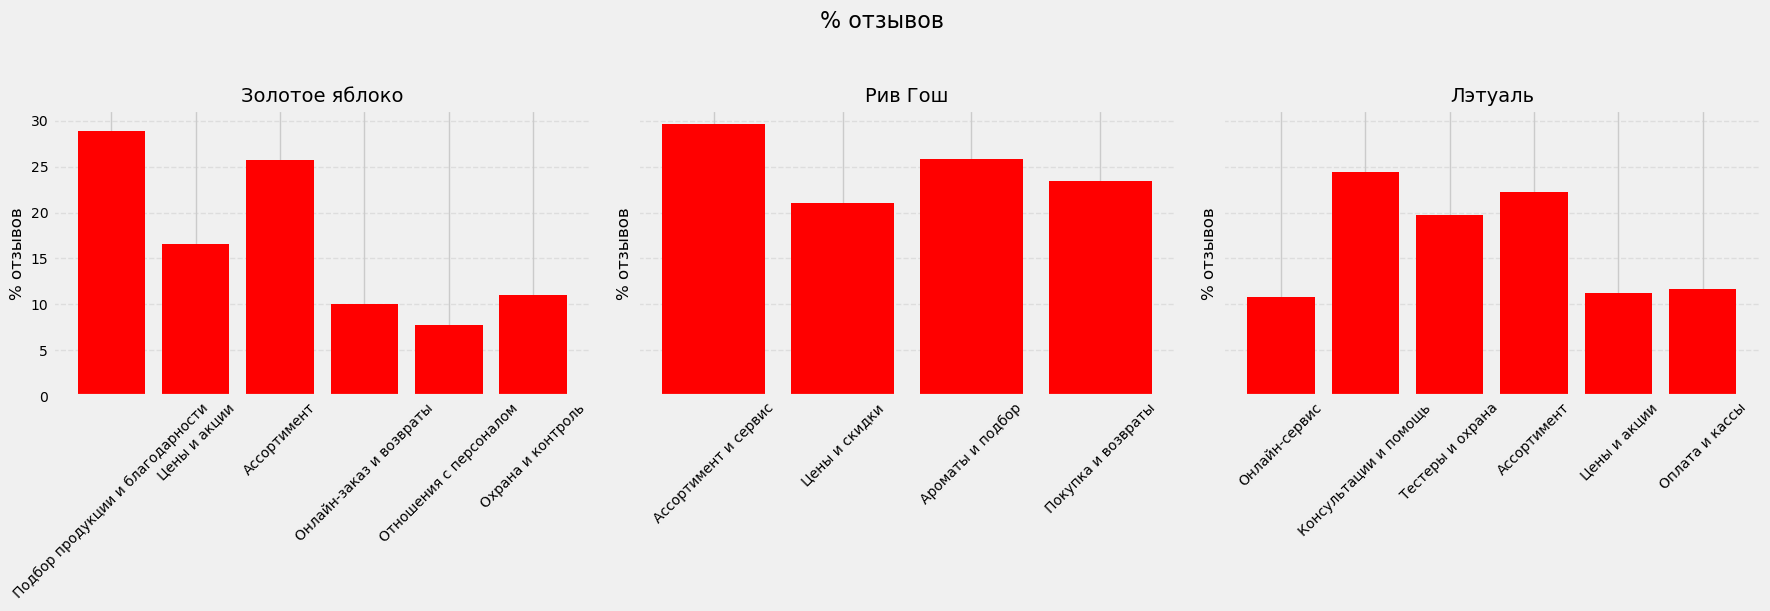

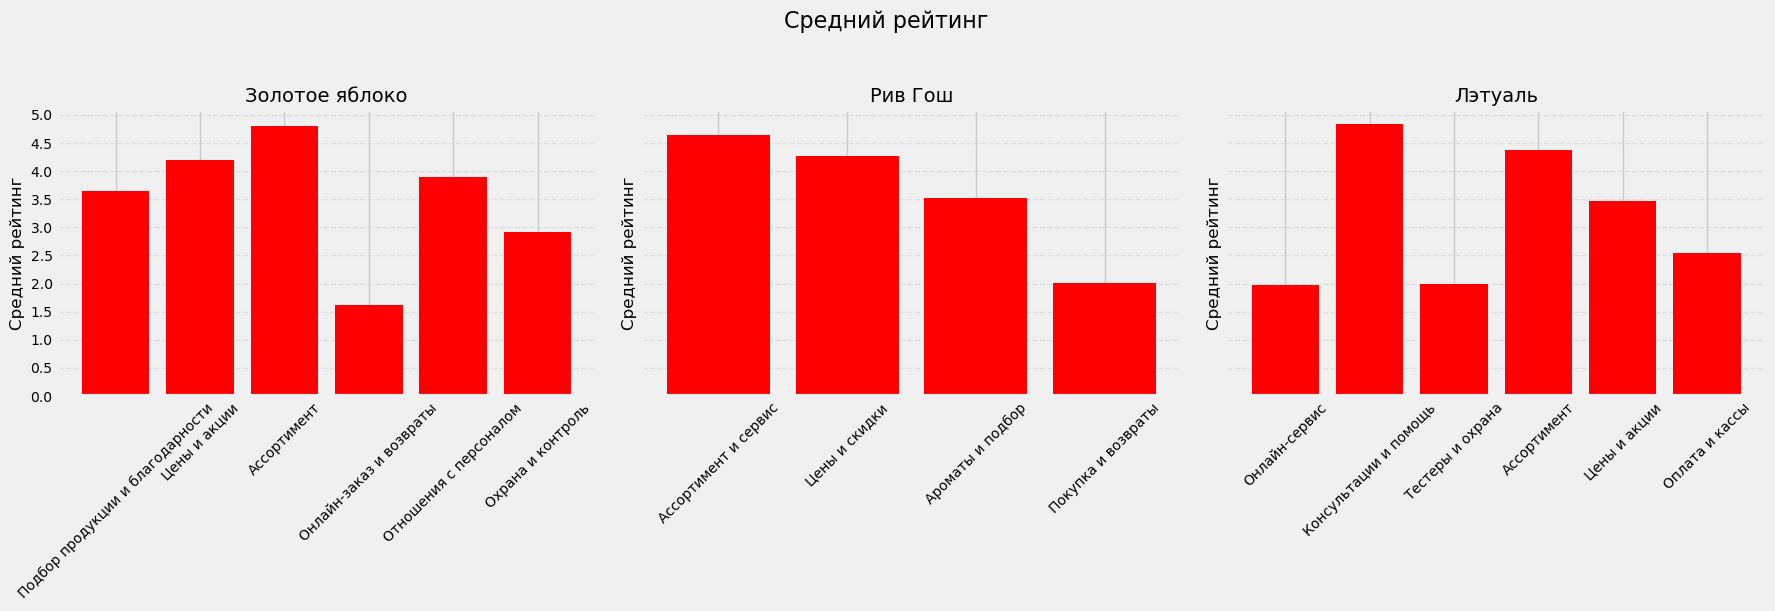

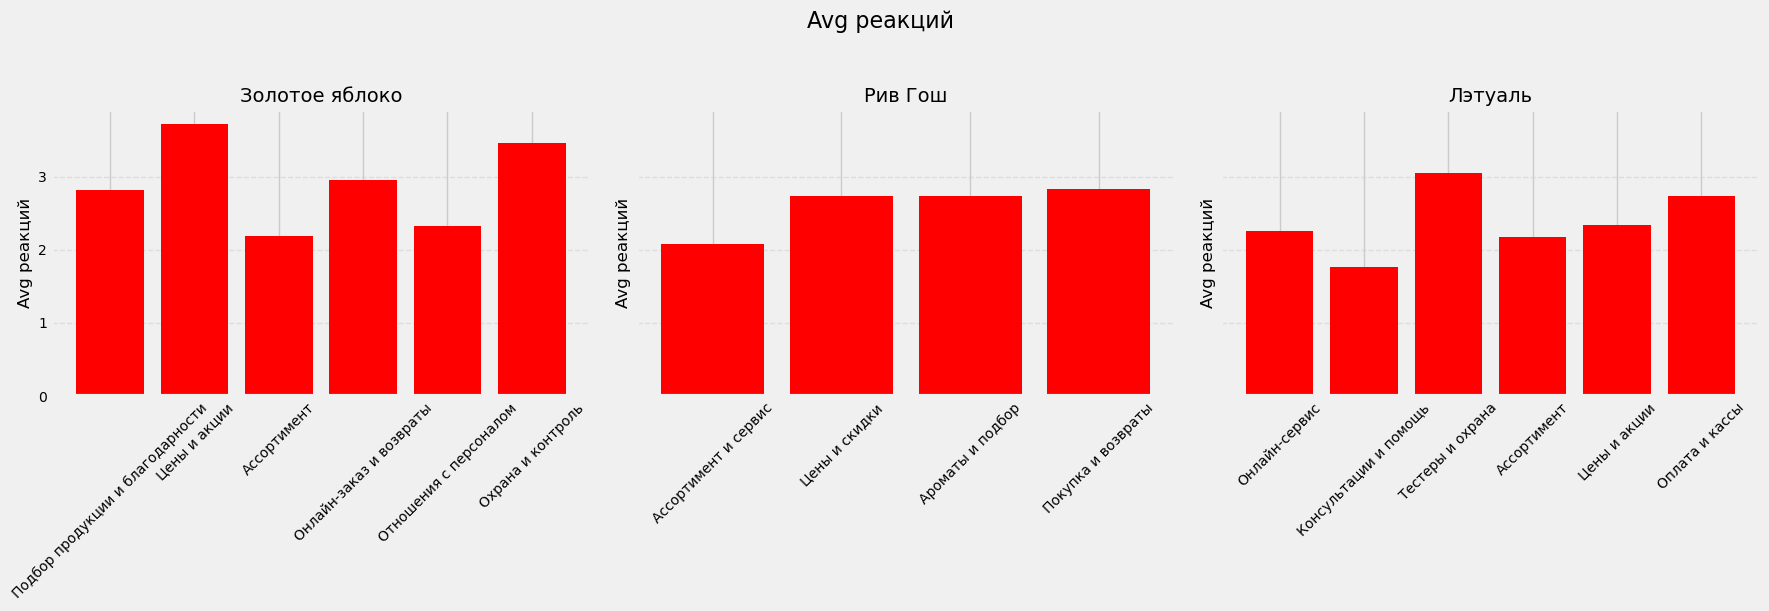

In [127]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.style.use('fivethirtyeight')
bar_color = '#ff0000'

# Параметры графиков для каждой метрики
plots = [
    ('pct_reviews',   '% отзывов',        5),   # деления по 5%
    ('avg_rating',    'Средний рейтинг',  0.5), # деления по 0.5 звезды
    ('avg_reactions', 'Avg реакций',      1)    # деления по 1 реакции
]

for metric, ylabel, ystep in plots:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
    for ax, chain in zip(axes, all_stats_df['chain'].unique()):
        df = all_stats_df[all_stats_df['chain'] == chain]
        ax.bar(df['topic_label'], df[metric], color=bar_color)
        ax.set_title(chain, fontsize=14)
        ax.set_xlabel('')
        ax.set_ylabel(ylabel, fontsize=12)

        # сетка по горизонтали и деления
        ax.grid(True, axis='y', linestyle='--', alpha=0.5)
        ax.yaxis.set_major_locator(ticker.MultipleLocator(ystep))
        ax.tick_params(axis='x', rotation=45, labelsize=10)
        ax.tick_params(axis='y', labelsize=10)

    fig.suptitle(ylabel, fontsize=16, y=1.02)
    fig.tight_layout()
    plt.show()
